# K-Nearest Neighbors (KNN)
Neste notebook vamos treinar um classificador KNN para prever `Attrition` dos funcionários.
Etapas: EDA -> Pré-processamento -> Treino (GridSearch) -> Avaliação -> Salvamento de artefatos

In [13]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
import joblib
sns.set(style='whitegrid')
RANDOM_STATE = 42

In [14]:
# Carregar dados
# Use path relative ao notebook - adjust se necessário
import os
nb_dir = os.path.dirname(__file__) if '__file__' in globals() else '.'
df = pd.read_csv(os.path.join(nb_dir, 'funcionarios.csv'))
print('Shape:', df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## EDA rápido
Verificar distribuição do alvo e algumas estatísticas.

Attrition
No     1233
Yes     237
Name: count, dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


C:\Users\ediad\AppData\Local\Temp\ipykernel_9616\3089185113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


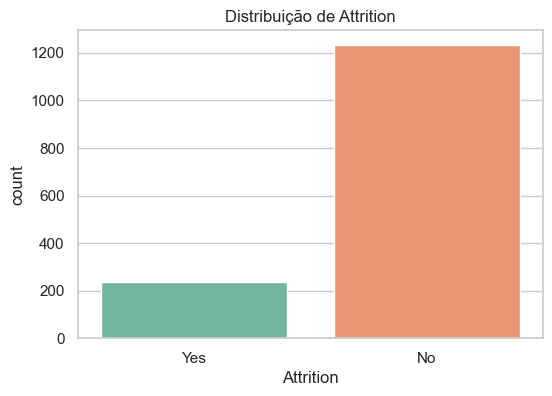

In [15]:
print(df['Attrition'].value_counts())
display(df.describe(include='all').T)
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Distribuição de Attrition')
plt.savefig('imagens/knn_attrition_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## Pré-processamento
Selecionar features, imputar, codificar categóricas e escalar numéricas.

In [16]:
# Separar X e y
target = 'Attrition'
y = df[target].map({'Yes':1, 'No':0}) if df[target].dtype == 'object' else df[target]

In [17]:
# Identificar colunas numéricas e categóricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
# Remover colunas que não são úteis/identificadores
for c in ['EmployeeNumber','EmployeeCount','StandardHours']:
    if c in num_cols: num_cols.remove(c)

print('Numeric cols:', len(num_cols), 'Categorical cols:', len(cat_cols))

Numeric cols: 23 Categorical cols: 9


In [18]:
# Construir transformadores
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

# Split treino/teste
X = df.drop(columns=[target]).copy()
# Garantir que o target não esteja na lista de categóricas (evita KeyError ao selecionar colunas)
if target in cat_cols:
    cat_cols.remove(target)

# Selecionar as colunas disponíveis
selected_cols = [c for c in (num_cols + cat_cols) if c in X.columns]
X = X[selected_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (1176, 31) Test shape: (294, 31)


## Treino com GridSearchCV
Pipeline com `preprocessor` + `KNeighborsClassifier` e GridSearch para `n_neighbors`, `weights` e `p`.

In [19]:
pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', KNeighborsClassifier())])
param_grid = {
    'clf__n_neighbors': [3,5,7,9],
    'clf__weights': ['uniform','distance'],
    'clf__p': [1,2]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)
print('Best CV f1:', gs.best_score_)
best_model = gs.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'uniform'}
Best CV f1: 0.2797544409613375


## Avaliação no conjunto de teste
Relatório de classificação, matriz de confusão e métricas principais.

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.55      0.26      0.35        47

    accuracy                           0.85       294
   macro avg       0.71      0.61      0.63       294
weighted avg       0.82      0.85      0.82       294

Accuracy: 0.8469387755102041
F1: 0.34782608695652173


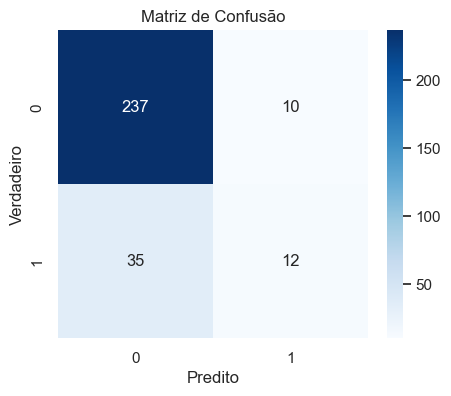

In [20]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.savefig('imagens/knn_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

In [21]:
# Salvar artefatos: modelo, y_test, y_pred
out_root = r'c:\\Users\\ediad\\OneDrive\\Documentos\\GitHub\\machine-learning-grupo4\\docs\\knn'
joblib.dump(best_model, out_root + r'\\knn_model.joblib')
pd.DataFrame(y_test).reset_index(drop=True).to_csv(out_root + r'\\knn_y_test.csv', index=False)
pd.DataFrame(y_pred, columns=['y_pred']).to_csv(out_root + r'\\knn_y_pred.csv', index=False)
print('Saved model and predictions to', out_root)

Saved model and predictions to c:\\Users\\ediad\\OneDrive\\Documentos\\GitHub\\machine-learning-grupo4\\docs\\knn


## Gráficos adicionais
Nesta seção adicionamos alguns gráficos úteis: ROC + Precision-Recall, distribuições das principais variáveis numéricas por `Attrition`, mapa de correlação entre numéricas, e uma projeção PCA 2D colorida por `Attrition`.

In [22]:
# 1) ROC Curve e Precision-Recall (se possível)
from sklearn.metrics import roc_curve, precision_recall_curve, auc

if hasattr(best_model, 'predict_proba'):
    y_scores = best_model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1],'k--', alpha=0.5)
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC Curve')
    plt.legend()
    plt.savefig('imagens/knn_roc.png', bbox_inches='tight', dpi=150)
    plt.close()

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f'PR (AUC = {pr_auc:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.savefig('imagens/knn_pr_curve.png', bbox_inches='tight', dpi=150)
    plt.close()
else:
    print('best_model does not support predict_proba; skipping ROC/PR')

In [23]:
# 2) Distribuições das principais variáveis numéricas por Attrition
num_show = 6
top_num = num_cols[:num_show]
for col in top_num:
    plt.figure(figsize=(6,3))
    sns.kdeplot(data=df, x=col, hue='Attrition', common_norm=False)
    plt.title(f'Distribuição de {col} por Attrition')
    plt.savefig(f'imagens/knn_dist_{col}.png', bbox_inches='tight', dpi=150)
    plt.close()

In [24]:
# 3) Mapa de correlação entre numéricas
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlação entre variáveis numéricas')
plt.savefig('imagens/knn_correlation.png', bbox_inches='tight', dpi=150)
plt.close()

In [25]:
# 4) PCA 2D colorido por Attrition (para ver separação)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_all = pd.concat([X_train, X_test])
X_all_proc = preprocessor.fit_transform(X_all)
X_pca = pca.fit_transform(X_all_proc)
labels_all = pd.concat([y_train, y_test]).reset_index(drop=True)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_all, cmap='coolwarm', s=10, alpha=0.8)
plt.title('PCA 2D - colorido por Attrition')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.savefig('imagens/knn_pca2d.png', bbox_inches='tight', dpi=150)
plt.close()